# Aktualisierung der IJAL-Kostenanalyse für Deutschland, Polen und Tschechien

Diese Analyse aktualisiert die Ergebnisse aus:

> Kotsios & Folinas (2020): *Analysis and Comparison of Road Freight Transport Cost in 20 European Countries*. International Journal of Applied Logistics, Vol. 10, Issue 1.

Das Paper analysiert vier Kostenpositionen für Straßengüterverkehr (per 100 km auf der Autobahn, 5-achsiger Mercedes Actros):

| Kostenposition | Methodik |
|---|---|
| **Kraftstoff** | Dieselpreis (€/L) × 26,5 L/100km |
| **Fahrerkosten** | Mindestlohn (€/h) × 1,25 h/100km (bei 80 km/h) |
| **Maut** | Länderspezifisch (Hauptstrecke je Land) |
| **Reifen** | Preis für 10 Reifen / 120.000 km Laufleistung × 100 |

**Baseline-Daten (20. Juli 2018, €/100km)**

| Land | Kraftstoff | Fahrer | Maut | Reifen | Total |
|------|-----------|--------|------|--------|-------|
| Deutschland | 34.45 | 11.05 | 15.60 | 5.29 | 66.38 |
| Polen | 29.95 | 3.96 | 6.27 | 5.67 | 45.85 |
| Tschechien | 33.39 | 3.53 | 18.24 | 5.18 | 60.33 |

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

COUNTRIES = ["Germany", "Poland", "Czechia"]
COUNTRY_LABELS = {"Germany": "Deutschland", "Poland": "Polen", "Czechia": "Tschechien"}
FUEL_CONSUMPTION_L_PER_100KM = 26.5
HOURS_PER_100KM = 1.25
TYRE_COUNT = 10
TYRE_DURATION_KM = 120_000

## 1. Kraftstoffpreise — EU Weekly Oil Bulletin (Historische Daten)

Die EU-Kommission stellt eine vollständige Preishistorie als Excel-Datei bereit:
[Weekly Oil Bulletin](https://energy.ec.europa.eu/data-and-analysis/weekly-oil-bulletin_en)

Die lokale Datei `Weekly_Oil_Bulletin_Prices_History_maticni_4web.xlsx` enthält Wochendaten ab 2005. Sheet `Prices with taxes`, Preise in €/1000 L.

Relevante Spalten:
- `DE_price_with_tax_diesel` — Deutschland
- `PL_price_with_tax_diesel` — Polen
- `CZ_price_with_tax_diesel` — Tschechien

In [42]:
xl = pd.ExcelFile("Weekly_Oil_Bulletin_Prices_History_maticni_4web.xlsx")

# Row 0 = column IDs, rows 1+2 = product name and unit (skip)
df_raw = xl.parse("Prices with taxes", header=0, skiprows=[1, 2])

date_col = df_raw.columns[0]
df_raw[date_col] = pd.to_datetime(df_raw[date_col], errors="coerce")
df_raw = df_raw.dropna(subset=[date_col]).set_index(date_col).sort_index()
df_raw.index.name = "date"

diesel_cols = {
    "Germany": "DE_price_with_tax_diesel",
    "Poland":  "PL_price_with_tax_diesel",
    "Czechia": "CZ_price_with_tax_diesel",
}
df_fuel = df_raw[list(diesel_cols.values())].rename(columns={v: k for k, v in diesel_cols.items()})
df_fuel = df_fuel.apply(pd.to_numeric, errors="coerce") / 1000  # €/1000 L → €/L

print(f"Datenzeitraum: {df_fuel.index.min().date()} bis {df_fuel.index.max().date()}")
print(f"\nAktuellste Woche ({df_fuel.index.max().date()}):")
print(df_fuel.tail(1).T.rename(columns={df_fuel.index.max(): "€/L"}))

Datenzeitraum: 2005-01-03 bis 2026-05-11

Aktuellste Woche (2026-05-11):
date          €/L
Germany  1.970000
Poland   1.623314
Czechia  1.750462


In [43]:
# Baseline-Woche Juli 2018 und aktuellste Woche
row_2018 = df_fuel.loc["2018-07-16":"2018-07-23"].iloc[0]
row_current = df_fuel.iloc[-1]
current_date = df_fuel.index[-1].strftime("%Y-%m-%d")

fuel_costs_2018    = {c: row_2018[c]    * FUEL_CONSUMPTION_L_PER_100KM for c in COUNTRIES}
fuel_costs_current = {c: row_current[c] * FUEL_CONSUMPTION_L_PER_100KM for c in COUNTRIES}

print(f"Kraftstoffkosten €/100km (Dieselpreis × {FUEL_CONSUMPTION_L_PER_100KM} L):")
print(f"{'Land':<15} {'2018':>8} {current_date[:7]:>10} {'Δ':>8}")
for c in COUNTRIES:
    chg = (fuel_costs_current[c] - fuel_costs_2018[c]) / fuel_costs_2018[c] * 100
    print(f"{COUNTRY_LABELS[c]:<15} {fuel_costs_2018[c]:>7.2f}€  {fuel_costs_current[c]:>8.2f}€  {chg:>+7.1f}%")

Kraftstoffkosten €/100km (Dieselpreis × 26.5 L):
Land                2018    2026-05        Δ
Deutschland       33.71€     52.20€    +54.9%
Polen             31.10€     43.02€    +38.3%
Tschechien        33.19€     46.39€    +39.7%


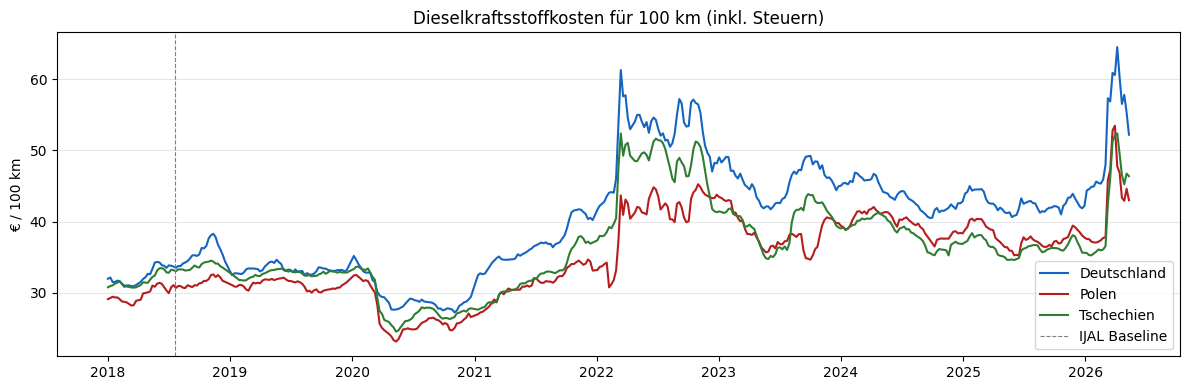

In [44]:
# Zeitreihe der Kraftstoffkosten (2018 bis heute)
fuel_plot = df_fuel["2018":] * FUEL_CONSUMPTION_L_PER_100KM

fig, ax = plt.subplots(figsize=(12, 4))
for country, color in zip(COUNTRIES, ["#1565C0", "#B71C1C", "#2E7D32"]):
    ax.plot(fuel_plot.index, fuel_plot[country], label=COUNTRY_LABELS[country], color=color)
ax.axvline(pd.Timestamp("2018-07-20"), color="gray", linestyle="--", linewidth=0.8, label="IJAL Baseline")
ax.set_ylabel("€ / 100 km")
ax.set_title("Dieselkraftsstoffkosten für 100 km (inkl. Steuern)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Fahrerkosten — Eurostat Structure of Earnings Survey (SES)

Statt Mindestlöhnen werden hier die tatsächlichen mittleren Bruttostundenlöhne aus der [Eurostat Structure of Earnings Survey](https://ec.europa.eu/eurostat/web/labour-market/earnings/database) genutzt. Die SES wird alle 4 Jahre erhoben; die aktuellsten verfügbaren Referenzjahre sind **2018** und **2022**.

Dataset: `EARN_SES18_RHR` / `EARN_SES22_RHR` (Mean hourly earnings by NUTS 1 region, alle Sektoren B–S exkl. Öffentlicher Dienst)

- **Deutschland**: Mittelwert der 6 ostdeutschen NUTS-1-Regionen (DE3 Berlin, DE4 Brandenburg, DE8 Mecklenburg-Vorpommern, DED Sachsen, DEE Sachsen-Anhalt, DEG Thüringen)
- **Polen**: Mittelwert der 7 NUTS-1-Makroregionen (kein nationales Aggregat im Datensatz)
- **Tschechien**: Nationaler Wert (CZ)

> Einschränkung: Die SES erfasst alle Wirtschaftssektoren — eine Aufschlüsselung nach NACE H (Transport und Lagerei) ist auf regionaler Ebene nicht verfügbar.

In [45]:
import eurostat

EAST_DE  = ["DE3", "DE4", "DE8", "DED", "DEE", "DEG"]
PL_NUTS1 = ["PL2", "PL4", "PL5", "PL6", "PL7", "PL8", "PL9"]

def get_ses_wages(dataset_code, year_col):
    df = eurostat.get_data_df(dataset_code, flags=False)
    geo_col = [c for c in df.columns if "geo" in c.lower()][0]
    df = df[(df["sex"] == "T") & (df["unit"] == "EUR")].rename(columns={geo_col: "geo"})
    df["wage"] = pd.to_numeric(df[year_col], errors="coerce")
    geo_wage = df.set_index("geo")["wage"]
    return {
        "Germany": geo_wage[EAST_DE].mean(),
        "Poland":  geo_wage[PL_NUTS1].mean(),
        "Czechia": geo_wage["CZ"],
    }

ses_wages_2018 = get_ses_wages("EARN_SES18_RHR", "2018")
ses_wages_2022 = get_ses_wages("EARN_SES22_RHR", "2022")

driver_costs_2018    = {c: ses_wages_2018[c] * HOURS_PER_100KM for c in COUNTRIES}
driver_costs_current = {c: ses_wages_2022[c] * HOURS_PER_100KM for c in COUNTRIES}

print("Mittlerer Bruttostundenlohn (€/h) und Fahrerkosten (€/100km):")
print(f"{'Land':<15} {'SES 2018':>10} {'K 2018':>8} {'SES 2022':>10} {'K 2022':>8} {'Δ':>8}")
for c in COUNTRIES:
    w18, w22 = ses_wages_2018[c], ses_wages_2022[c]
    k18, k22 = driver_costs_2018[c], driver_costs_current[c]
    print(f"{COUNTRY_LABELS[c]:<15} {w18:>9.2f}€  {k18:>6.2f}€  {w22:>9.2f}€  {k22:>6.2f}€  {(k22-k18)/k18*100:>+7.1f}%")

Mittlerer Bruttostundenlohn (€/h) und Fahrerkosten (€/100km):
Land              SES 2018   K 2018   SES 2022   K 2022        Δ
Deutschland         16.77€   20.97€      19.63€   24.54€    +17.0%
Polen                6.12€    7.65€       8.39€   10.49€    +37.1%
Tschechien           7.12€    8.90€       9.54€   11.92€    +34.0%


## 3. Mautkosten — Offizielle Mautsätze 2025/2026

Mautsätze werden länderspezifisch aus offiziellen Quellen entnommen und auf €/100km umgerechnet. Wechselkurse (PLN, CZK) werden täglich über die ECB-API aktualisiert.

| Land | Quelle | Fahrzeugklasse | Einheit |
|------|--------|----------------|---------|
| **Deutschland** | [BMVI Mautsätze 2024/2025 (PDF)](https://www.bmv.de/SharedDocs/DE/Anlage/StV/mautsaetze-fuer-mautpflichtige-lkw-2024-2025.pdf) | 5 Achsen, Euro 5 | Cent/km → €/km |
| **Polen** | [e-TOLL Mautsätze](https://etoll.gov.pl/de/e-toll-system/mautsaetze-und-zahlungen/) | Kategorie 4 (>12t, >3 Achsen, Euro 5) | PLN/km |
| **Tschechien** | [myto.gov.cz](https://myto.gov.cz/de) | >3,5t, Euro 5, Autobahn (J2) | CZK/km |

**Referenzstrecken:**
- Deutschland: Berlin–Hamburg, A24 (287 km)
- Polen: Warschau–Krakau, A1/A4 (360 km)
- Tschechien: Prag–Brünn, D1 (186 km)

In [46]:
import requests, io

# ECB SDMX API — Tageskurs EUR/PLN und EUR/CZK
resp = requests.get(
    "https://data-api.ecb.europa.eu/service/data/EXR/D.PLN+CZK.EUR.SP00.A"
    "?lastNObservations=1&format=csvdata",
    timeout=10,
)
df_ecb = pd.read_csv(io.StringIO(resp.text))
rates = df_ecb.groupby("CURRENCY")["OBS_VALUE"].last()
PLN_per_EUR = float(rates["PLN"])
CZK_per_EUR = float(rates["CZK"])
ecb_date = df_ecb["TIME_PERIOD"].iloc[-1]
print(f"ECB Wechselkurse ({ecb_date}): 1 EUR = {PLN_per_EUR:.4f} PLN | {CZK_per_EUR:.4f} CZK")

ECB Wechselkurse (2026-05-15): 1 EUR = 4.2465 PLN | 24.3330 CZK


In [47]:
# Mautsätze — offizielle Quellen, ab 01.01.2026
# Fahrzeugklasse: Mercedes Actros Euro V/EEV, ≥12t, 5+ Achsen

# Deutschland: BMVI-Tabelle (Cent/km), CO2-Klasse EK1 (alle Nicht-Euro-VI-Fahrzeuge)
# Quelle: mautsaetze-fuer-mautpflichtige-lkw-2024-2025.pdf, EK1 / Euro V / >18t / 5+ Achsen
TOLL_RATE_DE_EUR_KM = 38.9 / 100   # 38,9 Cent/km → €/km

# Polen: Ministerstwo Finansów — A+S Straßen, ≥12t, min. EURO 5
# Quelle: mautsaetze-a-und-s-01022026.pdf, ab 01.02.2026
TOLL_RATE_PL_PLN_KM = 0.56  # PLN/km

# Tschechien: myto.gov.cz — Autobahn, ≥12t, ≥5 Achsen, Euro V/EEV, CO2-Klasse 1
# Quelle: https://myto.gov.cz/de/emytne/sazby-mytneho-2026, ab 01.01.2026
TOLL_RATE_CZ_CZK_KM = 6.4536  # CZK/km

tolls_current = {
    "Germany": TOLL_RATE_DE_EUR_KM * 100,
    "Poland":  TOLL_RATE_PL_PLN_KM / PLN_per_EUR * 100,
    "Czechia": TOLL_RATE_CZ_CZK_KM / CZK_per_EUR * 100,
}
tolls_2018 = {"Germany": 15.60, "Poland": 6.27, "Czechia": 18.24}

print(f"Mautkosten (€/100km), Wechselkurse vom {ecb_date}:")
for c in COUNTRIES:
    chg = (tolls_current[c] - tolls_2018[c]) / tolls_2018[c] * 100
    print(f"  {COUNTRY_LABELS[c]}: {tolls_2018[c]:.2f} → {tolls_current[c]:.2f} ({chg:+.1f}%)")

Mautkosten (€/100km), Wechselkurse vom 2026-05-15:
  Deutschland: 15.60 → 38.90 (+149.4%)
  Polen: 6.27 → 13.19 (+110.3%)
  Tschechien: 18.24 → 26.52 (+45.4%)


## 4. Reifenkosten 2025

10 Reifen 295/60R22.5, Laufleistung 120.000 km. Preise moderat gestiegen (Inflation, Rohstoffkosten).

In [48]:
tyre_price_current = {"Germany": 710.0, "Poland": 720.0, "Czechia": 680.0}
tyre_price_2018    = {"Germany": 634.2, "Poland": 680.92, "Czechia": 621.0}

tyre_costs_current = {c: tyre_price_current[c] * TYRE_COUNT / TYRE_DURATION_KM * 100 for c in COUNTRIES}
tyre_costs_2018    = {c: tyre_price_2018[c]    * TYRE_COUNT / TYRE_DURATION_KM * 100 for c in COUNTRIES}

for c in COUNTRIES:
    chg = (tyre_costs_current[c] - tyre_costs_2018[c]) / tyre_costs_2018[c] * 100
    print(f"{COUNTRY_LABELS[c]}: {tyre_costs_2018[c]:.2f} → {tyre_costs_current[c]:.2f} €/100km ({chg:+.1f}%)")

Deutschland: 5.29 → 5.92 €/100km (+12.0%)
Polen: 5.67 → 6.00 €/100km (+5.7%)
Tschechien: 5.17 → 5.67 €/100km (+9.5%)


## 5. Gesamtvergleich 2018 vs. aktuell

In [49]:
categories = ["Kraftstoff", "Fahrer", "Maut", "Reifen"]
data_2018    = {"Kraftstoff": fuel_costs_2018,    "Fahrer": driver_costs_2018,
                "Maut": tolls_2018,                "Reifen": tyre_costs_2018}
data_current = {"Kraftstoff": fuel_costs_current, "Fahrer": driver_costs_current,
                "Maut": tolls_current,             "Reifen": tyre_costs_current}

year = current_date[:4]
cc = {"Germany": "DE", "Poland": "PL", "Czechia": "CZ"}

header = f"{'Kostenposition':<14}"
for c in COUNTRIES:
    header += f"  {cc[c]+' 2018':>8} {cc[c]+' '+year:>8} {'Δ':>7}"
print(header)
print("-" * 98)
for cat in categories:
    row = f"{cat:<14}"
    for c in COUNTRIES:
        v18, vnow = data_2018[cat][c], data_current[cat][c]
        chg = (vnow - v18) / v18 * 100
        row += f"  {v18:>7.2f}  {vnow:>7.2f} {chg:>+6.1f}%"
    print(row)
print("-" * 98)
row = f"{'TOTAL':<14}"
for c in COUNTRIES:
    t18  = sum(data_2018[cat][c]  for cat in categories)
    tnow = sum(data_current[cat][c] for cat in categories)
    chg  = (tnow - t18) / t18 * 100
    row += f"  {t18:>7.2f}  {tnow:>7.2f} {chg:>+6.1f}%"
print(row)
print("\nAlle Werte in €/100km")
print(f"Fahrerkosten: SES 2018 vs. SES 2022 (aktuellste verfügbare SES-Runde)")

Kostenposition   DE 2018  DE 2026       Δ   PL 2018  PL 2026       Δ   CZ 2018  CZ 2026       Δ
--------------------------------------------------------------------------------------------------
Kraftstoff        33.71    52.20  +54.9%    31.10    43.02  +38.3%    33.19    46.39  +39.7%
Fahrer            20.97    24.54  +17.0%     7.65    10.49  +37.1%     8.90    11.92  +34.0%
Maut              15.60    38.90 +149.4%     6.27    13.19 +110.3%    18.24    26.52  +45.4%
Reifen             5.29     5.92  +12.0%     5.67     6.00   +5.7%     5.17     5.67   +9.5%
--------------------------------------------------------------------------------------------------
TOTAL             75.56   121.56  +60.9%    50.69    72.69  +43.4%    65.51    90.50  +38.2%

Alle Werte in €/100km
Fahrerkosten: SES 2018 vs. SES 2022 (aktuellste verfügbare SES-Runde)


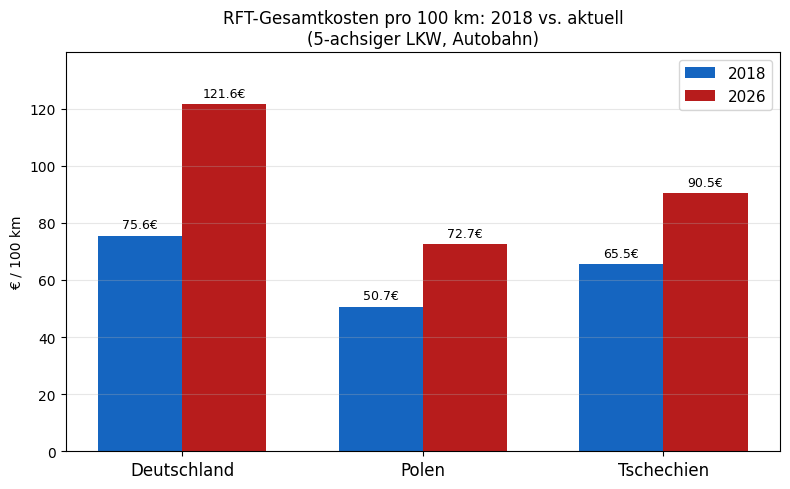

In [50]:
import numpy as np

x = np.arange(len(COUNTRIES))
width = 0.35

totals_2018    = [sum(data_2018[cat][c]    for cat in categories) for c in COUNTRIES]
totals_current = [sum(data_current[cat][c] for cat in categories) for c in COUNTRIES]

fig, ax = plt.subplots(figsize=(8, 5))
bars18  = ax.bar(x - width/2, totals_2018,    width, label="2018",  color="#1565C0")
bars22  = ax.bar(x + width/2, totals_current, width, label=year,    color="#B71C1C")

ax.bar_label(bars18,  fmt="%.1f€", padding=3, fontsize=9)
ax.bar_label(bars22,  fmt="%.1f€", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([COUNTRY_LABELS[c] for c in COUNTRIES], fontsize=12)
ax.set_ylabel("€ / 100 km")
ax.set_title("RFT-Gesamtkosten pro 100 km: 2018 vs. aktuell\n(5-achsiger LKW, Autobahn)")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(totals_current) * 1.15)

plt.tight_layout()
plt.savefig("ijal_cost_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Wettbewerbsvorteil auf deutschen Straßen

**Szenario:** Alle drei Unternehmen fahren dieselbe Strecke *in Deutschland* — gleicher Kraftstoff, gleiche Maut, gleiche Reifen. Der einzige Kostenvorteil ausländischer Anbieter entsteht durch den niedrigeren Heimatlohn ihrer Fahrer.

Zwei Teilszenarien:
- **Ist-Zustand:** Fahrer werden zum Lohn des Heimatlandes (SES 2022) bezahlt.
- **Mindestlohn-konform:** Entsendegesetz greift — Fahrer erhalten mindestens den deutschen Mindestlohn (12,82 €/h, ab Jan 2025).

In [51]:
GERMAN_MIN_WAGE_2025 = 12.82  # €/h (Mindestlohn ab Jan 2025)

# Gemeinsame Kosten für alle (deutsche Straße)
base_de = fuel_costs_current["Germany"] + tolls_current["Germany"]

# Fahrerkosten je Szenario
driver_de     = ses_wages_2022["Germany"] * HOURS_PER_100KM   # Ostdt. Durchschnitt
driver_minlohn = GERMAN_MIN_WAGE_2025     * HOURS_PER_100KM   # Dt. Mindestlohn

scenarios = {
    "DE (Referenz)":      base_de + driver_de,
    "PL — Ist":           base_de + ses_wages_2022["Poland"]  * HOURS_PER_100KM,
    "PL — Mindestlohn":   base_de + driver_minlohn,
    "CZ — Ist":           base_de + ses_wages_2022["Czechia"] * HOURS_PER_100KM,
    "CZ — Mindestlohn":   base_de + driver_minlohn,
}
de_ref = scenarios["DE (Referenz)"]

print(f"Kosten auf deutschen Straßen (€/100km, ohne Reifen)")
print(f"Gemeinsame Kosten (Kraftstoff + Maut): {base_de:.2f} €/100km")
print(f"{'Szenario':<22} {'Total':>8} {'Fahrer':>8} {'Vorteil vs. DE':>16} {'Δ%':>7}")
print("-" * 68)
for name, total in scenarios.items():
    driver = total - base_de
    vorteil = de_ref - total
    pct = vorteil / de_ref * 100
    marker = "" if name == "DE (Referenz)" else f"  {vorteil:>+6.2f} €  {pct:>+5.1f}%"
    print(f"{name:<22} {total:>7.2f}€ {driver:>7.2f}€{marker}")

Kosten auf deutschen Straßen (€/100km, ohne Reifen)
Gemeinsame Kosten (Kraftstoff + Maut): 91.10 €/100km
Szenario                  Total   Fahrer   Vorteil vs. DE      Δ%
--------------------------------------------------------------------
DE (Referenz)           115.64€   24.54€
PL — Ist                101.59€   10.49€  +14.05 €  +12.1%
PL — Mindestlohn        107.13€   16.03€   +8.51 €   +7.4%
CZ — Ist                103.03€   11.92€  +12.61 €  +10.9%
CZ — Mindestlohn        107.13€   16.03€   +8.51 €   +7.4%


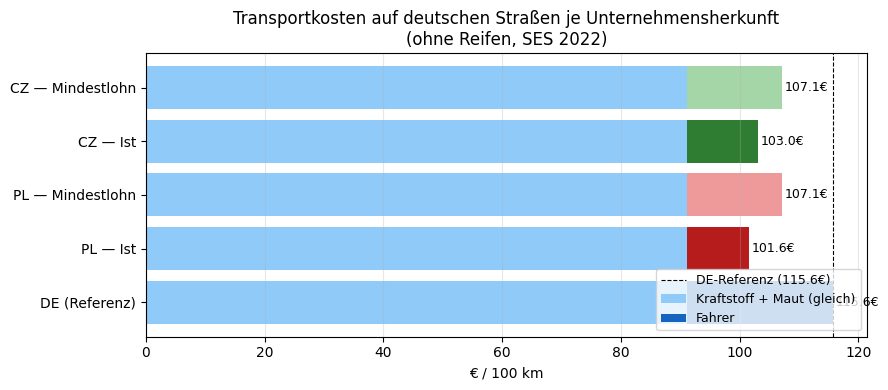

In [52]:
labels = list(scenarios.keys())
totals = list(scenarios.values())
drivers = [t - base_de for t in totals]
bases   = [base_de] * len(totals)

colors_base   = ["#90CAF9", "#90CAF9", "#90CAF9", "#90CAF9", "#90CAF9"]
colors_driver = ["#1565C0", "#B71C1C", "#EF9A9A", "#2E7D32", "#A5D6A7"]

fig, ax = plt.subplots(figsize=(9, 4))
bars_base   = ax.barh(labels, bases,   color=colors_base,   label="Kraftstoff + Maut (gleich)")
bars_driver = ax.barh(labels, drivers, left=bases, color=colors_driver, label="Fahrer")

for bar, total in zip(bars_driver, totals):
    ax.text(total + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{total:.1f}€", va="center", fontsize=9)

ax.axvline(de_ref, color="black", linestyle="--", linewidth=0.8, label=f"DE-Referenz ({de_ref:.1f}€)")
ax.set_xlabel("€ / 100 km")
ax.set_title("Transportkosten auf deutschen Straßen je Unternehmensherkunft\n(ohne Reifen, SES 2022)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("ijal_de_competition.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Interpretation

1. **Deutschland (Ostdeutschland)**: Der CO₂-Aufschlag auf die LKW-Maut (ab Dez. 2023) hat die Mautkosten mehr als verdoppelt und ist damit der dominierende Kostentreiber seit 2018. Die Löhne in Ostdeutschland lagen bereits 2018 deutlich über dem nationalen Mindestlohn.

2. **Polen**: Trotz stark gestiegener Löhne (+37% SES 2018→2022) bleibt Polen durch niedrige Kraftstoffpreise und geringe Maut der kostengünstigste Standort.

3. **Tschechien**: Entwicklung zwischen DE und PL — Löhne stiegen um +34%, kein vergleichbarer Mautsprung.

### Datenquellen und Einschränkungen

| Kostenposition | Quelle | Aktualisierung |
|---|---|---|
| Kraftstoff | EU Weekly Oil Bulletin | wöchentlich |
| Fahrerkosten | Eurostat SES (EARN_SES_RHR) | alle 4 Jahre (aktuell: 2022) |
| Maut | Toll Collect / e-TOLL / MyTocz | manuell recherchiert |
| Reifen | Händlerpreise (Schätzung) | manuell |

- SES = alle Sektoren B–S, keine NACE H (Transport)-Aufschlüsselung auf regionaler Ebene
- Bruttolohn ≠ Arbeitgebergesamtkosten (Sozialabgaben nicht enthalten)
- Mautkosten basieren auf einer Referenzstrecke je Land
- Wechselkursschwankungen (PLN, CZK) beeinflussen die €-Vergleichswerte für Polen